In [24]:
#Importing necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD

In [25]:
# 1. Data Ingestion & cleaning
df = pd.read_csv('wine_data.csv')
df = df.dropna()
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         21000 non-null  float64
 1   volatile_acidity      21000 non-null  float64
 2   citric_acid           21000 non-null  float64
 3   residual_sugar        21000 non-null  float64
 4   chlorides             21000 non-null  float64
 5   free_sulfur_dioxide   21000 non-null  float64
 6   total_sulfur_dioxide  21000 non-null  float64
 7   density               21000 non-null  float64
 8   pH                    21000 non-null  float64
 9   sulphates             21000 non-null  float64
 10  alcohol               21000 non-null  float64
 11  quality               21000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 1.9 MB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,9.797079,0.774796,0.793870,31.289348,0.200245,129.442333,229.008762,1.009972,3.158712,1.020641,11.291716,6.000000
std,2.413919,0.365015,0.384833,19.015391,0.124933,77.167262,100.183265,0.012032,0.171371,0.408304,1.182198,2.000048
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,7.600000,0.430000,0.410000,9.800000,0.072000,45.000000,150.000000,0.997417,3.030000,0.620000,10.400000,4.000000
50%,10.000000,0.830000,0.870000,37.600000,0.205000,145.800000,240.500000,1.012200,3.150000,1.080000,11.300000,6.000000
75%,11.800000,1.080000,1.110000,46.800000,0.298000,194.325000,311.625000,1.019840,3.270000,1.360000,12.200000,8.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
# Checking for missing values
df.isnull().sum()
df = df.dropna()

In [ ]:
# Encoding categorical variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [ ]:
# Splitting the dataset into features and target variable
X = df.drop("quality", axis=1)
y = df["quality"]

In [ ]:
# Checking the unique classes in the target variable
print("Classes :", np.unique(y))
num_classes = len(np.unique(y))
print("Number of Classes :", num_classes)

Classes : [3 4 5 6 7 8 9]
Number of Classes : 7


In [ ]:
# Normalizing the features
from tensorflow.keras.utils import to_categorical
y = to_categorical(y - y.min())

In [ ]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y.argmax(axis=1)
)

In [ ]:
# Normalizing the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Building the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

c:\Users\yashg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
#Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Training the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es]
)

Epoch 1/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2670 - loss: 1.8840 - val_accuracy: 0.3018 - val_loss: 1.6229
Epoch 2/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2837 - loss: 1.6766 - val_accuracy: 0.3021 - val_loss: 1.6025
Epoch 3/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2944 - loss: 1.6327 - val_accuracy: 0.3030 - val_loss: 1.5935
Epoch 4/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2947 - loss: 1.6111 - val_accuracy: 0.3021 - val_loss: 1.5895
Epoch 5/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3046 - loss: 1.6003 - val_accuracy: 0.2970 - val_loss: 1.5945
Epoch 6/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2931 - loss: 1.5995 - val_accuracy: 0.2982 - val_loss: 1.5864
Epoch 7/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3010 - loss: 1.5898 - val_accuracy: 0.2973 - val_loss: 1.5928
Epoch 8/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2999 - loss: 1.5895 - val_accu

In [ ]:
# Evaluating the model on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [42]:
# Evaluating the model
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("Classification Report:")
print(classification_report(y_true, y_pred))

Accuracy : 0.32142857142857145
Confusion Matrix:
[[224  19   4   2   0   4 347]
 [178  29  23  16   6   5 343]
 [ 63   6 264 167   3   2  95]
 [ 12   2 115 421  33   0  17]
 [124  11   4 177  41   1 242]
 [222  24   1  24  16   8 305]
 [208  21   0   0   4   4 363]]
Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.37      0.27       600
           1       0.26      0.05      0.08       600
           2       0.64      0.44      0.52       600
           3       0.52      0.70      0.60       600
           4       0.40      0.07      0.12       600
           5       0.33      0.01      0.03       600
           6       0.21      0.60      0.31       600

    accuracy                           0.32      4200
   macro avg       0.37      0.32      0.28      4200
weighted avg       0.37      0.32      0.28      4200



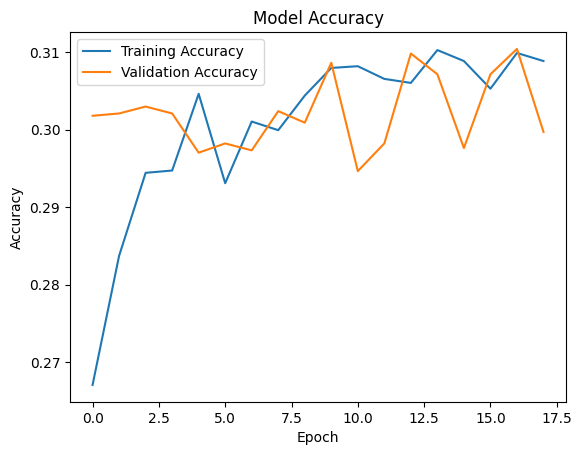

In [ ]:
# Visualizing the training history
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

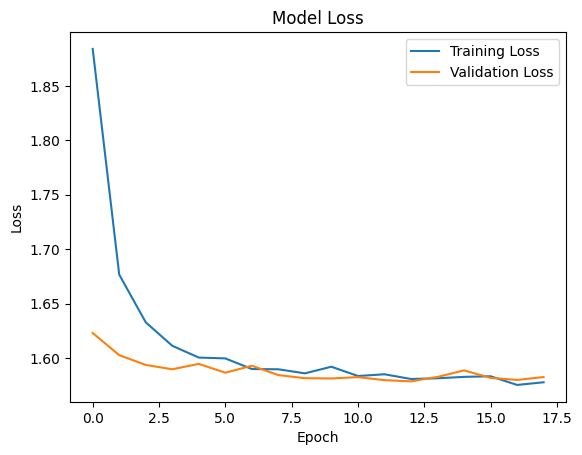

In [ ]:
# Visualizing the training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()